Initialized Grid Network: 25 nodes, 40 edges.
Defender pure strategies: 300
Attacker pure strategies: 300

--- Game Theoretic Analysis Results ---
Optimal Defender Strategy (Harden Nodes): (0, 1)
Optimal Attacker Strategy (Target Nodes): (0, 1)
Security Level Value (Worst-case guaranteed resilience): 88.00%


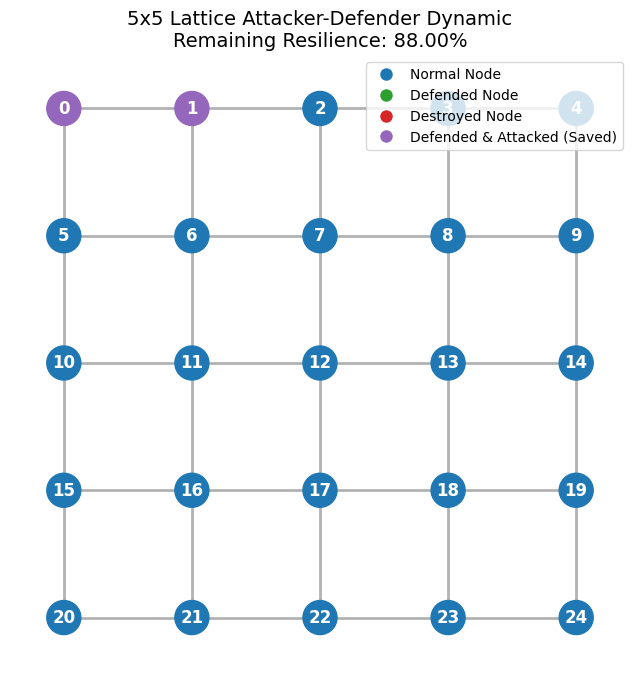

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import itertools

# ---------------------------------------------------------
# 1. SETUP THE TOPOLOGY (5x5 Grid / Lattice)
# ---------------------------------------------------------
# Create a 5x5 2D grid graph (25 nodes total, labeled 0 to 24)
GRID_SIZE = 5
G = nx.grid_2d_graph(GRID_SIZE, GRID_SIZE)

# Relabel nodes from tuples (x, y) to plain integers 0 to 24 for easier indexing
G = nx.convert_node_labels_to_integers(G)

# Define resource constraints for the strategic game
DEFENDER_BUDGET = 2  # Number of nodes the defender can harden
ATTACKER_BUDGET = 2  # Number of nodes the attacker can target

print(f"Initialized Grid Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges.")

# ---------------------------------------------------------
# 2. DEFINE THE RESILIENCE METRIC (Game Payoff)
# ---------------------------------------------------------
def evaluate_network_resilience(graph, attacked_nodes, defended_nodes):
    """
    Simulates the simultaneous actions and returns the payoff.
    - If a node is defended, it resists the attack.
    - If a node is attacked and NOT defended, it is removed from the network.
    - Returns the fraction of nodes remaining in the Largest Connected Component (LCC).
    """
    # Create a copy of the graph to simulate destruction
    sim_graph = graph.copy()
    
    # Identify which attacked nodes actually fail (attacked AND not defended)
    successful_attacks = [node for node in attacked_nodes if node not in defended_nodes]
    
    # Remove failed nodes from the network
    sim_graph.remove_nodes_from(successful_attacks)
    
    # Calculate the size of the Largest Connected Component (LCC)
    if sim_graph.number_of_nodes() == 0:
        return 0.0
        
    components = list(nx.connected_components(sim_graph))
    largest_component_size = max(len(c) for c in components)
    
    # Normalize by the original graph size to get a metric between 0 and 1
    resilience_score = largest_component_size / graph.number_of_nodes()
    return resilience_score

# ---------------------------------------------------------
# 3. COMPUTE GAME PAYOFF MATRIX (Strategic Interaction)
# ---------------------------------------------------------
# Generate all possible pure strategies for both players based on their budgets
all_nodes = list(G.nodes())
defender_strategies = list(itertools.combinations(all_nodes, DEFENDER_BUDGET))
attacker_strategies = list(itertools.combinations(all_nodes, ATTACKER_BUDGET))

print(f"Defender pure strategies: {len(defender_strategies)}")
print(f"Attacker pure strategies: {len(attacker_strategies)}")

# We will populate a game matrix where:
# Row index = Defender strategy
# Column index = Attacker strategy
# Value = Network resilience (Defender wants to maximize this, Attacker wants to minimize it)
payoff_matrix = np.zeros((len(defender_strategies), len(attacker_strategies)))

# (Optional optimization: Evaluate a smaller subset or compute the full matrix)
# For a 5x5 grid with budget=2, combinations are 300 each, making a 300x300 matrix (90,000 evaluations)
for i, def_strat in enumerate(defender_strategies):
    for j, atk_strat in enumerate(attacker_strategies):
        payoff_matrix[i, j] = evaluate_network_resilience(G, atk_strat, def_strat)

# ---------------------------------------------------------
# 4. ANALYZE STRATEGIC OUTCOMES (Maximin / Minimax)
# ---------------------------------------------------------
# Defender's pessimistic optimal choice (Maximin): Maximize the minimum remaining resilience
min_payoffs_per_def_strat = np.min(payoff_matrix, axis=1)
best_def_idx = np.argmax(min_payoffs_per_def_strat)
optimal_defense = defender_strategies[best_def_idx]
guaranteed_resilience = min_payoffs_per_def_strat[best_def_idx]

# Attacker's worst-case choice (Minimax): Minimize the maximum remaining resilience
max_payoffs_per_atk_strat = np.max(payoff_matrix, axis=0)
best_atk_idx = np.argmin(max_payoffs_per_atk_strat)
optimal_attack = attacker_strategies[best_atk_idx]
worst_case_resilience = max_payoffs_per_atk_strat[best_atk_idx]

print("\n--- Game Theoretic Analysis Results ---")
print(f"Optimal Defender Strategy (Harden Nodes): {optimal_defense}")
print(f"Optimal Attacker Strategy (Target Nodes): {optimal_attack}")
print(f"Security Level Value (Worst-case guaranteed resilience): {guaranteed_resilience:.2%}")

# ---------------------------------------------------------
# 5. VISUALIZE THE GAME SCENARIO
# ---------------------------------------------------------
# Create fixed coordinates for standard 5x5 grid layout
pos = {n: (n % GRID_SIZE, GRID_SIZE - 1 - (n // GRID_SIZE)) for n in G.nodes()}

plt.figure(figsize=(8, 8))

# Color coding the nodes based on the strategic outcome
node_colors = []
for node in G.nodes():
    if node in optimal_defense and node in optimal_attack:
        node_colors.append("tab:purple")  # Attack absorbed by defense
    elif node in optimal_defense:
        node_colors.append("tab:green")   # Successfully defended
    elif node in list(set(optimal_attack) - set(optimal_defense)):
        node_colors.append("tab:red")     # Successfully destroyed node
    else:
        node_colors.append("tab:blue")    # Untouched, functional node

# Draw the infrastructure network topology
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=600)
nx.draw_networkx_labels(G, pos, font_color="white", font_weight="bold")
nx.draw_networkx_edges(G, pos, width=2, edge_color="gray", alpha=0.6)

# Create a custom legend for clarity
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', markersize=10, label='Normal Node'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:green', markersize=10, label='Defended Node'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:red', markersize=10, label='Destroyed Node'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:purple', markersize=10, label='Defended & Attacked (Saved)'),
]
plt.legend(handles=legend_elements, loc="upper right")
plt.title(f"5x5 Lattice Attacker-Defender Dynamic\nRemaining Resilience: {guaranteed_resilience:.2%}", fontsize=14)
plt.axis("off")
plt.show()